In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.optim as optim
import matplotlib.pyplot as plt
!pip -q install kneed
from kneed import KneeLocator
import gc, time
from google.colab import drive
import sys
from pathlib import Path

drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/cuffless-bp-pulsedb")
DATA_DIR = Path("/content/drive/MyDrive/pulsedb")
PROCESSED_DIR = PROJECT_DIR / "processed"
RESULTS_DIR = PROJECT_DIR / "results"
FIG_DIR = PROJECT_DIR / "figures"

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

Mounted at /content/drive


In [ ]:
ABP_train = np.load(f"{PROCESSED_DIR}/abp_train_sample.npy")

print(ABP_train.shape)
print(ABP_train.dtype)

(5000, 1250)
float32


Elbow point (best n_components): 99
Best cumulative_variance_ratio : 0.9804441


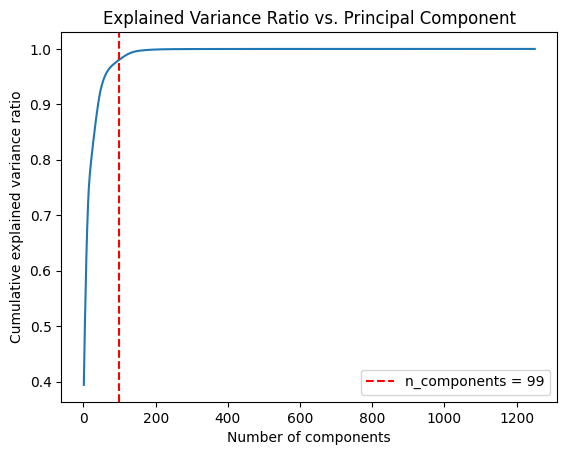

In [ ]:
# First, perform a Principle Component Analysis (PCA) to understand the dimensionality of the ABP signals.
# Perform an “elbow analysis” to determine the intrinsic linear dimension of the data.

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

ABP_scaled = StandardScaler().fit_transform(ABP_train)
pca = PCA()
ABP_pca = pca.fit_transform(ABP_scaled)
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# print("Explained variance ratio:", explained_variance_ratio)
# print("Cumulative explained variance ratio:", cumulative_variance_ratio)

knee = KneeLocator(
    range(1,1251),
    cumulative_variance_ratio,
    curve='concave',
    direction='increasing'
)
print("Elbow point (best n_components):", knee.knee)
print("Best cumulative_variance_ratio :", knee.knee_y)

# Plot the explained variance ratio
plt.plot(range(1,1251), cumulative_variance_ratio)
plt.axvline(x=knee.knee, color='r', linestyle='--', label=f'n_components = {knee.knee}')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance ratio')
plt.title('Explained Variance Ratio vs. Principal Component')
plt.legend()

plt.savefig(f"{FIG_DIR}/pca_elbow.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
ABP_0_org = ABP_train[0].copy()

# normalization
mean = np.mean(ABP_train)
std = np.std(ABP_train)
ABP_train -= mean
ABP_train /= std

# wrap in PyTorch TensorDatasets and DataLoaders
ABP_loader = DataLoader(TensorDataset(torch.from_numpy(ABP_train.astype(np.float32))), batch_size=512, shuffle=False)

In [ ]:
from src.train import elbow_AE

In [ ]:
latent_list = list(range(50,150))
results, ABP_gen = elbow_AE(latent_list, ABP_loader, ABP_train[0])

Knee (latent dim) suggested: 84


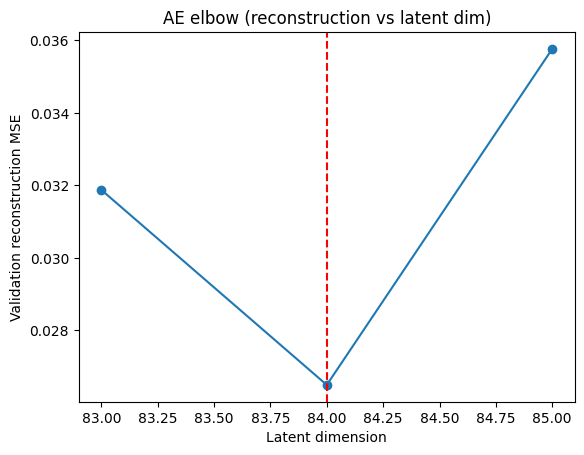

In [ ]:
results_df = pd.DataFrame(results)
results_df.to_csv(f"{RESULTS_DIR}/representation_results.csv", index=False)

knee = KneeLocator(results_df['latent_dim'], results_df['mse'], curve='convex', direction='decreasing')
print("Knee (latent dim) suggested:", knee.knee)

# plot elbow: latent_dim vs reconstruction error
# plt.figure(figsize=(6,4))
plt.plot(results_df['latent_dim'], results_df['mse'], marker='o')
plt.axvline(x=knee.knee, color='r', linestyle='--', label=f'latent_dim = {knee.knee}')
plt.xlabel("Latent dimension")
plt.ylabel("Validation reconstruction MSE")
plt.title("AE elbow (reconstruction vs latent dim)")
plt.savefig(f"{FIG_DIR}/AE_elbow.png", dpi=300, bbox_inches="tight")
plt.show()

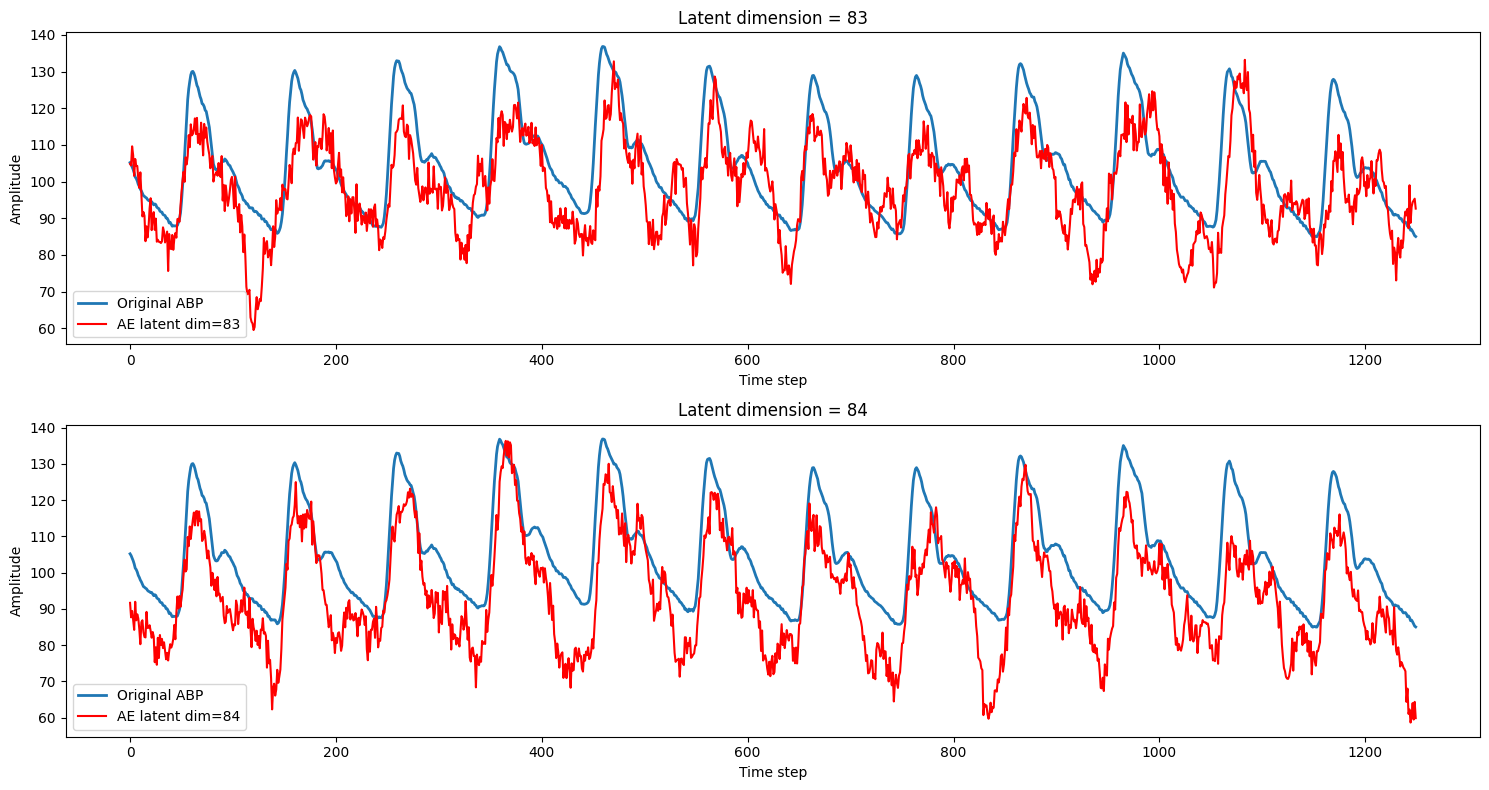

In [ ]:
# Use the decoder to generate some new ABP signals. Include plots with examples of both data and generated signals

latent_to_plot = [2, 81, 274]
n_plots = len(latent_to_plot)
plt.figure(figsize=(15, 4*n_plots))

for i, ld in enumerate(latent_to_plot, 1):
    ABP_gen_unnormalized = ABP_gen[ld]['generated']*std+mean
    plt.subplot(n_plots, 1, i)
    plt.plot(ABP_0_org, label="Original ABP", linewidth=2)
    plt.plot(ABP_gen_unnormalized, label=f"AE latent dim={ld}", color='r')
    plt.xlabel("Time step")
    plt.ylabel("Amplitude")
    plt.title(f"Latent dimension = {ld}")
    plt.legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/generated_signals.png", dpi=300, bbox_inches="tight")
plt.show()